# Waveform-based clustering of neural units using 3D PCA

This notebook performs an unsupervised clustering analysis of single-unit electrophysiological recordings based on waveform-derived features.

The objective is to provide a clear, reproducible and portfolio-ready analysis pipeline:

1. load processed unit-level features;
2. clean and validate the dataset;
3. standardize waveform and firing-rate features;
4. project the feature space into three principal components;
5. cluster units with K-Means;
6. interpret clusters as putative excitatory and inhibitory units;
7. export both static publication-style figures and an interactive 3D PCA visualization.

Raw electrophysiological recordings are not included in this repository because of size and sharing constraints.  
This notebook starts from processed CSV outputs generated upstream.


## 1. Setup

The analysis uses standard Python tools for data manipulation, machine learning and visualization.

Static figures are generated with Matplotlib for README/report integration.  
Interactive figures are generated with Plotly so that the 3D PCA can be rotated directly inside the notebook or exported as an HTML file.


In [17]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - required for 3D projection

warnings.filterwarnings("ignore", category=UserWarning)

# Project paths
DATA_PATH = Path("data/processed/combined_results.csv")
OUTPUT_DATA_PATH = Path("data/processed/unit_waveform_clusters.csv")
FIGURES_DIR = Path("figures")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

# Reproducibility
RANDOM_STATE = 42


## 2. Load the processed unit-level dataset

Each row corresponds to one recorded neural unit.

Expected identifiers:

- `mouse_id`: animal identifier;
- `group`: experimental group, for example 5-MeO-DMT or saline;
- `unit_id`: neural unit identifier.

Expected numerical features:

- waveform duration;
- half-width duration;
- peak/amplitude asymmetry;
- peak-to-trough ratio;
- duration between peaks;
- one-minus-left-peak;
- area after the minimum;
- repolarization slope;
- firing rate.

These variables summarize unit waveform morphology and activity level, which are commonly used as lightweight proxies for exploratory cell-type classification.


In [18]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (602, 12)


,mouse_id,group,unit_id,duration,half_width_duration,peak_amplitude_asymmetry,peak_to_trough_ratio,duration_between_peaks,one_minus_left_peak,area_after_min,repolarization_slope,firing_rate
0,F3876,saline,58,0.733333,0.2,0.202905,0.250144,1.166667,0.376931,16.892292,0.313247,1.761538
1,F3876,saline,66,0.733333,0.2,0.202905,0.250144,1.166667,0.376931,16.892292,0.313247,0.283077
2,F3876,saline,72,0.733333,0.2,0.285377,0.264681,1.133333,0.353312,20.466541,0.366222,2.164615
3,F3876,saline,80,0.733333,0.2,0.285377,0.264681,1.133333,0.353312,20.466541,0.366222,1.046154
4,F3876,saline,104,0.866667,0.2,0.198973,0.265009,1.300000,0.338119,18.538962,0.267026,6.638462


In [19]:
display(df.info())
display(df.describe(include="all").T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   mouse_id                  602 non-null    object 
 1   group                     602 non-null    object 
 2   unit_id                   602 non-null    int64  
 3   duration                  602 non-null    float64
 4   half_width_duration       602 non-null    float64
 5   peak_amplitude_asymmetry  602 non-null    float64
 6   peak_to_trough_ratio      602 non-null    float64
 7   duration_between_peaks    602 non-null    float64
 8   one_minus_left_peak       602 non-null    float64
 9   area_after_min            602 non-null    float64
 10  repolarization_slope      581 non-null    float64
 11  firing_rate               602 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 56.6+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
mouse_id,602,11,F3797,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
group,602,2,5-Meo,361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unit_id,602.0,NaN,NaN,NaN,265.709302,135.50555,39.0,157.25,247.0,347.0,639.0
duration,602.0,NaN,NaN,NaN,0.693079,0.209318,0.166667,0.6,0.7,0.8,1.233333
half_width_duration,602.0,NaN,NaN,NaN,0.242193,0.11253,0.066667,0.2,0.233333,0.266667,1.166667
peak_amplitude_asymmetry,602.0,NaN,NaN,NaN,0.271572,2.113646,-9.560599,0.067776,0.21051,0.363875,35.426904
peak_to_trough_ratio,602.0,NaN,NaN,NaN,0.335103,0.162146,0.009202,0.246869,0.27845,0.331725,0.989609
duration_between_peaks,602.0,NaN,NaN,NaN,1.132503,0.247422,0.333333,1.0,1.133333,1.233333,1.833333
one_minus_left_peak,602.0,NaN,NaN,NaN,-0.11138,0.970151,-6.407983,-0.496151,0.173569,0.376931,2.707503
area_after_min,602.0,NaN,NaN,NaN,28.022937,16.863742,0.199746,18.883291,22.277857,30.254808,124.02611


## 3. Data validation and cleaning

The goal of this section is to make the notebook robust and explicit.

Instead of silently assuming that all columns are present, the notebook checks the expected identifiers and features.  
Rows with missing values are removed only for the columns required in this analysis.


In [20]:
identifier_cols = ["mouse_id", "group", "unit_id"]

feature_cols = [
    "duration",
    "half_width_duration",
    "peak_amplitude_asymmetry",
    "peak_to_trough_ratio",
    "duration_between_peaks",
    "one_minus_left_peak",
    "area_after_min",
    "repolarization_slope",
    "firing_rate",
]

required_cols = identifier_cols + feature_cols
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(
        "The following required columns are missing from the dataset: "
        + ", ".join(missing_cols)
    )

df_clean = df.copy()

# Standardize identifier formatting.
df_clean["group"] = df_clean["group"].astype(str).str.strip()
df_clean["mouse_id"] = df_clean["mouse_id"].astype(str)
df_clean["unit_id"] = df_clean["unit_id"].astype(str)

missing_before = df_clean[required_cols].isna().sum().sort_values(ascending=False)
display(missing_before[missing_before > 0])

n_before = len(df_clean)
df_clean = df_clean.dropna(subset=required_cols).reset_index(drop=True)
n_after = len(df_clean)

print(f"Rows before cleaning: {n_before}")
print(f"Rows after cleaning:  {n_after}")
print(f"Rows removed:         {n_before - n_after}")


repolarization_slope    21
dtype: int64

Rows before cleaning: 602
Rows after cleaning:  581
Rows removed:         21


## 4. Feature scaling

PCA and K-Means are sensitive to the scale of the input variables.

For example, firing rate and waveform duration are expressed in different numerical ranges.  
Standardization is therefore required so that no feature dominates the PCA or the clustering only because of its unit of measurement.


In [21]:
X = df_clean[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=df_clean.index)

display(X_scaled_df.head())


,duration,half_width_duration,peak_amplitude_asymmetry,peak_to_trough_ratio,duration_between_peaks,one_minus_left_peak,area_after_min,repolarization_slope,firing_rate
0,0.128913,-0.322342,-0.117525,-0.510140,0.173522,0.474458,-0.687800,-0.585663,-0.671186
1,0.128913,-0.322342,-0.117525,-0.510140,0.173522,0.474458,-0.687800,-0.585663,-0.812131
2,0.128913,-0.322342,-0.074807,-0.419241,0.037834,0.450274,-0.476632,-0.451509,-0.632760
3,0.128913,-0.322342,-0.074807,-0.419241,0.037834,0.450274,-0.476632,-0.451509,-0.739385
4,0.805199,-0.322342,-0.119562,-0.417189,0.716274,0.434718,-0.590514,-0.702712,-0.206258


## 5. Three-dimensional PCA

Principal Component Analysis is used to project the standardized waveform feature space into three dimensions.

A 3D PCA is useful here because it preserves more structure than a 2D projection while remaining visually interpretable.  
The explained variance of each component is reported to quantify how much information is retained in the projection.


In [22]:
pca = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled_df)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2", "PC3"],
    index=df_clean.index,
)

pca_df = pd.concat(
    [df_clean[identifier_cols].reset_index(drop=True), pca_df.reset_index(drop=True)],
    axis=1,
)

explained_variance = pca.explained_variance_ratio_

print("Explained variance ratio:")
for i, var in enumerate(explained_variance, start=1):
    print(f"PC{i}: {var:.2%}")

print(f"Total variance explained by PC1-PC3: {explained_variance.sum():.2%}")

display(pca_df.head())


Explained variance ratio:
PC1: 29.76%
PC2: 23.07%
PC3: 17.51%
Total variance explained by PC1-PC3: 70.35%


,mouse_id,group,unit_id,PC1,PC2,PC3
0,F3876,saline,58,-0.538778,0.112619,-0.533598
1,F3876,saline,66,-0.544892,0.088343,-0.464094
2,F3876,saline,72,-0.347358,0.110460,-0.373028
3,F3876,saline,80,-0.351983,0.092095,-0.320448
4,F3876,saline,104,-1.068756,-0.259581,-0.640781


## 6. K-Means clustering in the 3D PCA space

K-Means is applied to the three-dimensional PCA representation.

The analysis uses two clusters because the aim is to obtain a simple waveform-based separation between broad-spiking and narrow-spiking units.  
The resulting clusters are interpreted as:

- **putative excitatory units**: typically broader waveform profile;
- **putative inhibitory units**: typically narrower waveform profile and often higher firing rate.

This interpretation is biologically plausible but remains indirect.  
It should be described as **putative**, not definitive, because waveform-based clustering alone does not prove cell identity.


In [23]:
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_pca)

df_clean["cluster"] = clusters
pca_df["cluster"] = clusters

sil_score = silhouette_score(X_pca, clusters)
print(f"Silhouette score: {sil_score:.3f}")

# Cluster interpretation rule:
# the cluster with the shortest mean waveform duration is labelled as putative inhibitory.
cluster_means = df_clean.groupby("cluster")[["duration", "half_width_duration", "firing_rate"]].mean()

inhibitory_cluster = cluster_means["duration"].idxmin()
excitatory_cluster = [cluster for cluster in cluster_means.index if cluster != inhibitory_cluster][0]

cluster_label_map = {
    excitatory_cluster: "Putative Excitatory Unit",
    inhibitory_cluster: "Putative Inhibitory Unit",
}

df_clean["cluster_label"] = df_clean["cluster"].map(cluster_label_map)
pca_df["cluster_label"] = pca_df["cluster"].map(cluster_label_map)

cluster_interpretation = cluster_means.assign(
    interpreted_label=cluster_means.index.map(cluster_label_map)
)

display(cluster_interpretation)


Silhouette score: 0.389


,duration,half_width_duration,firing_rate,interpreted_label
cluster,,,,
0,0.756748,0.259837,10.036702,Putative Excitatory Unit
1,0.590838,0.172320,5.841736,Putative Inhibitory Unit


## 7. Interactive 3D PCA visualization

The interactive version is designed for exploration.

In the notebook, the figure can be rotated, zoomed and inspected point by point.  
The same figure is also exported as an HTML file that can be shared in a portfolio repository.


In [24]:
try:
    import plotly.express as px

    fig_interactive = px.scatter_3d(
        pca_df,
        x="PC1",
        y="PC2",
        z="PC3",
        color="cluster_label",
        hover_data={
            "mouse_id": True,
            "group": True,
            "unit_id": True,
            "PC1": ":.2f",
            "PC2": ":.2f",
            "PC3": ":.2f",
        },
        title="Interactive 3D PCA of waveform-derived unit features",
        opacity=0.85,
    )

    fig_interactive.update_traces(marker=dict(size=4))

    fig_interactive.update_layout(
        width=900,
        height=700,
        scene=dict(
            xaxis_title=f"PC1 ({explained_variance[0] * 100:.1f}%)",
            yaxis_title=f"PC2 ({explained_variance[1] * 100:.1f}%)",
            zaxis_title=f"PC3 ({explained_variance[2] * 100:.1f}%)",
        ),
        legend_title_text="Cluster interpretation",
    )

    interactive_path = FIGURES_DIR / "interactive_3d_pca_waveform_clusters.html"
    fig_interactive.write_html(interactive_path, include_plotlyjs="cdn")

    print(f"Saved interactive figure: {interactive_path}")
    fig_interactive.show()

except ImportError:
    print(
        "Plotly is not installed. Install it with `pip install plotly` "
        "to enable the interactive 3D PCA figure."
    )


Saved interactive figure: figures\interactive_3d_pca_waveform_clusters.html


## 8. Static publication-style figures

The following figures are optimized for a README, a report or a portfolio page.

- **Figure A** shows the global 3D PCA structure across all units.
- **Figure B** shows the same PCA projection after K-Means clustering, with a pie chart summarizing cluster proportions.

The figures are exported as high-resolution PNG files and as SVG files for vector-based editing if needed.


In [25]:
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "figure.dpi": 120,
    "savefig.dpi": 600,
})

cluster_colors = {
    "Putative Excitatory Unit": "#E6CF27",
    "Putative Inhibitory Unit": "#5B3A64",
}

all_units_color = "#3558A8"


def pc_label(pc_index: int) -> str:
    """Return a formatted PCA axis label with explained variance."""
    return f"PC{pc_index} ({explained_variance[pc_index - 1] * 100:.0f}%)"


def style_3d_axis(ax, elev: int = 18, azim: int = -62) -> None:
    """Apply a minimal 3D axis style suitable for portfolio figures."""
    ax.grid(False)

    ax.xaxis.pane.set_alpha(0)
    ax.yaxis.pane.set_alpha(0)
    ax.zaxis.pane.set_alpha(0)

    ax.xaxis.line.set_color("black")
    ax.yaxis.line.set_color("black")
    ax.zaxis.line.set_color("black")

    ax.tick_params(axis="both", which="major", labelsize=7, pad=0)

    # Hide numeric ticks to keep the figure visually clean.
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect((1.25, 1.0, 0.9))


def save_figure(fig, stem: str) -> None:
    """Save a Matplotlib figure in both PNG and SVG formats."""
    png_path = FIGURES_DIR / f"{stem}.png"
    svg_path = FIGURES_DIR / f"{stem}.svg"

    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")

    print(f"Saved: {png_path}")
    print(f"Saved: {svg_path}")


Saved: figures\figure_A_waveforms_3d_pca_all_units.png
Saved: figures\figure_A_waveforms_3d_pca_all_units.svg


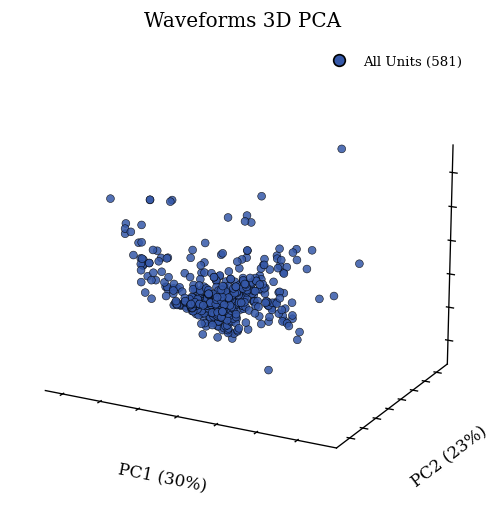

In [26]:
# Figure A: all units in the 3D PCA space.

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    pca_df["PC3"],
    s=22,
    c=all_units_color,
    edgecolor="black",
    linewidth=0.35,
    alpha=0.85,
)

style_3d_axis(ax)
ax.set_xlabel(pc_label(1), labelpad=6)
ax.set_ylabel(pc_label(2), labelpad=6)
ax.set_zlabel(pc_label(3), labelpad=6)
ax.set_title("Waveforms 3D PCA", pad=10)

legend_handle = Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    label=f"All Units ({len(pca_df)})",
    markerfacecolor=all_units_color,
    markeredgecolor="black",
    markersize=7,
)

ax.legend(handles=[legend_handle], loc="upper right", frameon=False)

plt.tight_layout()
save_figure(fig, "figure_A_waveforms_3d_pca_all_units")
plt.show()


Saved: figures\figure_B_waveforms_3d_pca_kmeans_clusters.png
Saved: figures\figure_B_waveforms_3d_pca_kmeans_clusters.svg


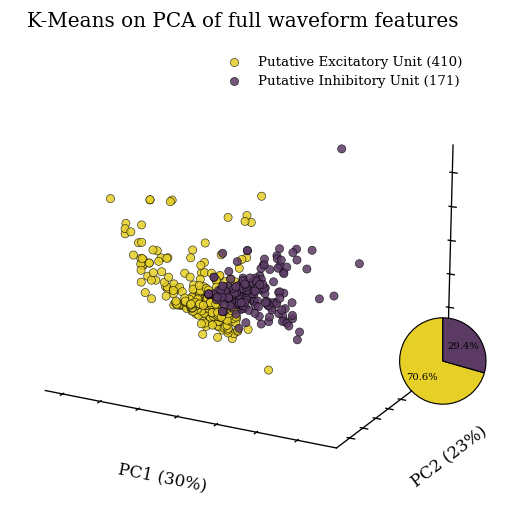

In [27]:
# Figure B: K-Means clusters in the 3D PCA space.

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

for label, subset in pca_df.groupby("cluster_label"):
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        s=24,
        c=cluster_colors[label],
        edgecolor="black",
        linewidth=0.35,
        alpha=0.85,
        label=f"{label} ({len(subset)})",
    )

style_3d_axis(ax)
ax.set_xlabel(pc_label(1), labelpad=6)
ax.set_ylabel(pc_label(2), labelpad=6)
ax.set_zlabel(pc_label(3), labelpad=6)
ax.set_title("K-Means on PCA of full waveform features", pad=10)
ax.legend(loc="upper right", frameon=False)

# Pie chart inset summarizing cluster proportions.
pie_ax = fig.add_axes([0.70, 0.26, 0.18, 0.18])
counts = pca_df["cluster_label"].value_counts()

pie_labels = list(cluster_colors.keys())
pie_values = [counts.get(label, 0) for label in pie_labels]
pie_colors = [cluster_colors[label] for label in pie_labels]

pie_ax.pie(
    pie_values,
    colors=pie_colors,
    autopct=lambda percentage: f"{percentage:.1f}%",
    startangle=90,
    textprops={"fontsize": 6},
    wedgeprops={"edgecolor": "black", "linewidth": 0.7},
)
pie_ax.set_aspect("equal")

plt.tight_layout()
save_figure(fig, "figure_B_waveforms_3d_pca_kmeans_clusters")
plt.show()


Saved: figures\figure_AB_waveforms_3d_pca_kmeans_panel.png
Saved: figures\figure_AB_waveforms_3d_pca_kmeans_panel.svg


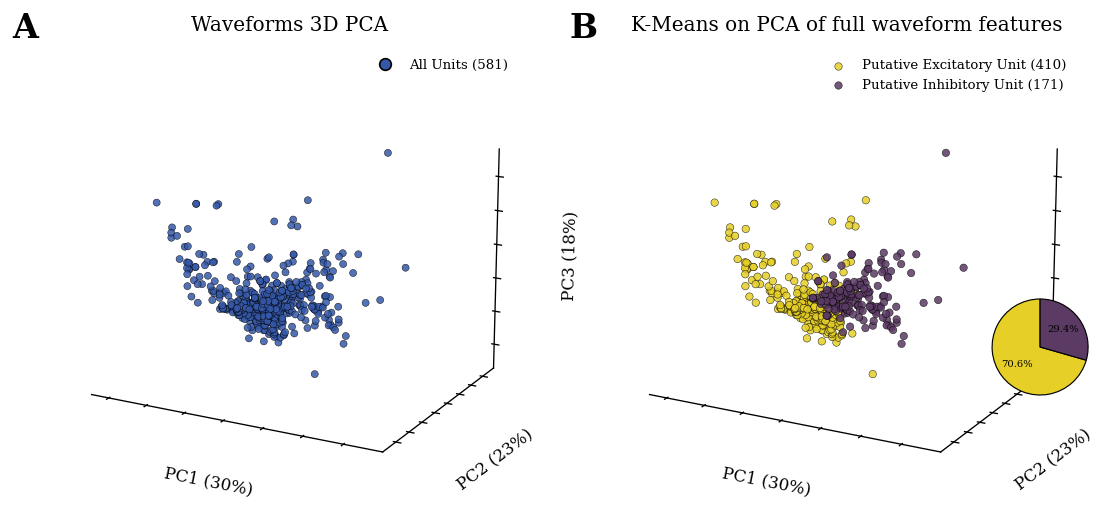

In [28]:
# Combined Figure A/B: useful for a README header or a report panel.

fig = plt.figure(figsize=(11, 5))

# Panel A
ax_a = fig.add_subplot(121, projection="3d")
ax_a.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    pca_df["PC3"],
    s=18,
    c=all_units_color,
    edgecolor="black",
    linewidth=0.30,
    alpha=0.85,
)
style_3d_axis(ax_a)
ax_a.set_xlabel(pc_label(1), labelpad=6)
ax_a.set_ylabel(pc_label(2), labelpad=6)
ax_a.set_zlabel(pc_label(3), labelpad=6)
ax_a.set_title("Waveforms 3D PCA", pad=10)
ax_a.legend(handles=[legend_handle], loc="upper right", frameon=False)
ax_a.text2D(-0.10, 1.02, "A", transform=ax_a.transAxes, fontsize=20, fontweight="bold")

# Panel B
ax_b = fig.add_subplot(122, projection="3d")
for label, subset in pca_df.groupby("cluster_label"):
    ax_b.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        s=20,
        c=cluster_colors[label],
        edgecolor="black",
        linewidth=0.30,
        alpha=0.85,
        label=f"{label} ({len(subset)})",
    )

style_3d_axis(ax_b)
ax_b.set_xlabel(pc_label(1), labelpad=6)
ax_b.set_ylabel(pc_label(2), labelpad=6)
ax_b.set_zlabel(pc_label(3), labelpad=6)
ax_b.set_title("K-Means on PCA of full waveform features", pad=10)
ax_b.legend(loc="upper right", frameon=False)
ax_b.text2D(-0.10, 1.02, "B", transform=ax_b.transAxes, fontsize=20, fontweight="bold")

# Pie inset for panel B.
pie_ax = fig.add_axes([0.82, 0.28, 0.10, 0.20])
pie_ax.pie(
    pie_values,
    colors=pie_colors,
    autopct=lambda percentage: f"{percentage:.1f}%",
    startangle=90,
    textprops={"fontsize": 6},
    wedgeprops={"edgecolor": "black", "linewidth": 0.7},
)
pie_ax.set_aspect("equal")

plt.tight_layout()
save_figure(fig, "figure_AB_waveforms_3d_pca_kmeans_panel")
plt.show()


## 9. Cluster summaries

These tables make the clustering interpretable and auditable.

The first table reports the number and percentage of units in each cluster.  
The second table reports descriptive statistics of the input features by interpreted cluster label.


In [29]:
cluster_counts = df_clean["cluster_label"].value_counts()
cluster_percentages = df_clean["cluster_label"].value_counts(normalize=True) * 100

cluster_summary = pd.DataFrame({
    "n_units": cluster_counts,
    "percentage": cluster_percentages.round(2),
})

display(cluster_summary)


,n_units,percentage
cluster_label,,
Putative Excitatory Unit,410,70.57
Putative Inhibitory Unit,171,29.43


In [30]:
cluster_feature_summary = (
    df_clean
    .groupby("cluster_label")[feature_cols]
    .agg(["mean", "median", "std"])
    .T
)

display(cluster_feature_summary)


cluster_label                    Putative Excitatory Unit  \
duration                 mean                    0.756748   
                         median                  0.733333   
                         std                     0.160647   
half_width_duration      mean                    0.259837   
                         median                  0.233333   
                         std                     0.112089   
peak_amplitude_asymmetry mean                    0.357508   
                         median                  0.205268   
                         std                     1.464273   
peak_to_trough_ratio     mean                    0.333591   
                         median                  0.280316   
                         std                     0.158973   
duration_between_peaks   mean                    1.190488   
                         median                  1.166667   
                         std                     0.215014   
one_minus_left_peak      mean                    0.138842   
                         median                  0.232122   
                         std                     0.564490   
area_after_min           mean                   21.301663   
                         median                 21.172124   
                         std                     5.656741   
repolarization_slope     mean                    0.335695   
                         median                  0.325716   
                         std                     0.111805   
firing_rate              mean                   10.036702   
                         median                  6.181538   
                         std                    11.260646   

cluster_label                    Putative Inhibitory Unit  
duration                 mean                    0.590838  
                         median                  0.666667  
                         std                     0.226310  
half_width_duration      mean                    0.172320  
                         median                  0.166667  
                         std                     0.050364  
peak_amplitude_asymmetry mean                    0.603123  
                         median                  0.251548  
                         std                     2.745346  
peak_to_trough_ratio     mean                    0.327262  
                         median                  0.268385  
                         std                     0.163035  
duration_between_peaks   mean                    0.964717  
                         median                  0.966667  
                         std                     0.242582  
one_minus_left_peak      mean                   -0.626616  
                         median                 -0.684509  
                         std                     1.441303  
area_after_min           mean                   45.874818  
                         median                 43.214310  
                         std                    21.760461  
repolarization_slope     mean                    1.045197  
                         median                  0.978592  
                         std                     0.381479  
firing_rate              mean                    5.841736  
                         median                  3.167692  
                         std                     7.647898

## 10. PCA loadings

PCA loadings help interpret what each principal component represents.

A high absolute loading means that the original feature contributes strongly to the corresponding principal component.  
This is useful for explaining whether PC1, PC2 or PC3 is mostly driven by waveform duration, waveform shape, repolarization slope or firing rate.


In [31]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=feature_cols,
)

display(loadings)

for pc in ["PC1", "PC2", "PC3"]:
    print(f"\nTop contributors to {pc}:")
    display(
        loadings[[pc]]
        .assign(abs_loading=loadings[pc].abs())
        .sort_values("abs_loading", ascending=False)
        .head(5)
    )


,PC1,PC2,PC3
duration,-0.389311,-0.419039,0.014236
half_width_duration,-0.441216,-0.004222,0.307067
peak_amplitude_asymmetry,0.037921,0.395906,0.327461
peak_to_trough_ratio,-0.182534,0.344118,0.527137
duration_between_peaks,-0.453931,-0.292579,0.092347
one_minus_left_peak,-0.169432,0.562962,-0.033272
area_after_min,0.323694,-0.324515,0.445891
repolarization_slope,0.526866,-0.108289,0.262247
firing_rate,0.043380,0.172233,-0.493128



Top contributors to PC1:


,PC1,abs_loading
repolarization_slope,0.526866,0.526866
duration_between_peaks,-0.453931,0.453931
half_width_duration,-0.441216,0.441216
duration,-0.389311,0.389311
area_after_min,0.323694,0.323694



Top contributors to PC2:


,PC2,abs_loading
one_minus_left_peak,0.562962,0.562962
duration,-0.419039,0.419039
peak_amplitude_asymmetry,0.395906,0.395906
peak_to_trough_ratio,0.344118,0.344118
area_after_min,-0.324515,0.324515



Top contributors to PC3:


,PC3,abs_loading
peak_to_trough_ratio,0.527137,0.527137
firing_rate,-0.493128,0.493128
area_after_min,0.445891,0.445891
peak_amplitude_asymmetry,0.327461,0.327461
half_width_duration,0.307067,0.307067


## 11. Export clustered dataset

The final CSV contains the original identifiers, cluster assignment, interpreted cluster label and the numerical features used in the analysis.

This file can be reused in downstream analyses, for example to compare neural responses between experimental groups.


In [32]:
output_cols = identifier_cols + ["cluster", "cluster_label"] + feature_cols

df_clean[output_cols].to_csv(OUTPUT_DATA_PATH, index=False)

print(f"Saved clustered dataset: {OUTPUT_DATA_PATH}")


Saved clustered dataset: data\processed\unit_waveform_clusters.csv


## 12. Interpretation and limitations

The 3D PCA projection reduces the waveform feature space into three interpretable axes while preserving more variance than a 2D projection.

K-Means identifies two waveform-based clusters.  
These clusters are interpreted as putative neural populations:

- **putative excitatory units**: broader waveform profile;
- **putative inhibitory units**: narrower waveform profile and often higher firing rate.

This classification should be treated as an exploratory proxy rather than definitive cell-type identification.  
A stronger biological conclusion would require additional validation, such as optogenetic tagging, anatomical information, genetic markers, or complementary electrophysiological criteria.

For a portfolio, the important point is that this notebook demonstrates a complete data-analysis workflow:

1. clear data validation;
2. feature standardization;
3. dimensionality reduction;
4. unsupervised clustering;
5. interpretable cluster labelling;
6. reproducible figure export;
7. transparent discussion of limitations.
